# Exploratory Data Analysis (EDA): SNAP Eligibility and Household Characteristics

## Objective
This analysis explores household-level socioeconomic data to understand:

1. Low-income households
2. SNAP eligibility gap (eligible but not receiving benefits)
3. Household composition (children, elderly)
4. Financial stress indicators such as rent burden

The goal is to identify patterns and characteristics of vulnerable populations.

In [44]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#load file
df= pd.read_csv("../data/processed/processed_all_households_blind.csv")




In [45]:
df.head()
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 61071 entries, 0 to 61070
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   SERIALNO                     61071 non-null  str    
 1   PUMA                         61071 non-null  int64  
 2   TARGET_GAP                   61071 non-null  int64  
 3   HAS_ELDERLY                  61071 non-null  int64  
 4   HAS_DISABLED                 61071 non-null  int64  
 5   NUM_CHILDREN                 61071 non-null  int64  
 6   NUM_WORKING_ADULTS           61071 non-null  int64  
 7   MAX_EDUCATION                61071 non-null  float64
 8   IS_MINORITY_HH               61071 non-null  int64  
 9   VEH                          61071 non-null  float64
 10  ACCESSINET                   61071 non-null  float64
 11  GRPIP                        61071 non-null  float64
 12  RMSP                         61071 non-null  float64
 13  NP                         

,PUMA,TARGET_GAP,HAS_ELDERLY,HAS_DISABLED,NUM_CHILDREN,NUM_WORKING_ADULTS,MAX_EDUCATION,IS_MINORITY_HH,VEH,ACCESSINET,...,SMARTPHONE_ONLY,INTERNET_DEVICE_INTERACTION,HOUSING_QUALITY_INDEX,AMENITY_COUNT,LOW_AMENITIES,LIMITED_ENGLISH,ENGLISH_ONLY,PERSONS_PER_ROOM,CROWDED_HH,CHILD_AND_SENIOR_HH
count,61071.000000,61071.000000,61071.000000,61071.000000,61071.000000,61071.000000,61071.000000,61071.000000,61071.000000,61071.000000,...,61071.000000,61071.000000,61071.000000,61071.000000,61071.000000,61071.000000,61071.000000,61071.000000,61071.000000,61071.000000
mean,16077.134745,0.080709,0.474382,0.248825,0.473351,1.234629,20.003357,0.402548,1.891814,1.115767,...,0.000557,0.010561,6.283834,0.031210,0.996201,0.023595,0.821519,0.401560,0.001294,0.017783
std,24860.895978,0.272390,0.499347,0.432336,0.926233,0.976882,2.852295,0.490415,1.120146,0.444303,...,0.023589,0.171785,0.586961,0.360905,0.061518,0.151786,0.382920,0.283049,0.035943,0.132161
min,101.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.052632,0.000000,0.000000
25%,1002.000000,0.000000,0.000000,0.000000,0.000000,0.000000,19.000000,0.000000,1.000000,1.000000,...,0.000000,0.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.222222,0.000000,0.000000
50%,5901.000000,0.000000,0.000000,0.000000,0.000000,1.000000,21.000000,0.000000,2.000000,1.000000,...,0.000000,0.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.333333,0.000000,0.000000
75%,16101.000000,0.000000,1.000000,0.000000,1.000000,2.000000,22.000000,1.000000,2.000000,1.000000,...,0.000000,0.000000,7.000000,0.000000,1.000000,0.000000,1.000000,0.500000,0.000000,0.000000
max,81003.000000,1.000000,1.000000,1.000000,10.000000,9.000000,24.000000,1.000000,6.000000,3.000000,...,1.000000,3.000000,7.000000,6.000000,1.000000,1.000000,1.000000,7.000000,1.000000,1.000000


### 1. People who receive SNAP


Use ['LOW_INCOME_FLAG==1'] to see how many people receive snap because this dataset does not explicitly indicating SNAP participation.

In [11]:
total_households = len(df)
low_income = df[df['LOW_INCOME_FLAG'] == 1]

print("Total households:", total_households)
print("Low-income households:", len(low_income))
print("Percentage:", len(low_income) / total_households * 100)

Total households: 61071
Low-income households: 22901
Percentage: 37.49897660100538


### 2. Poor People (LOW_INCOME_FLAG)


In [12]:
poor = df[df['LOW_INCOME_FLAG'] == 1]

print("Number of poor households:", len(poor))
print("Percentage:", len(poor) / len(df) * 100)
poor.describe()

Number of poor households: 22901
Percentage: 37.49897660100538


,PUMA,TARGET_GAP,HAS_ELDERLY,HAS_DISABLED,NUM_CHILDREN,NUM_WORKING_ADULTS,MAX_EDUCATION,IS_MINORITY_HH,VEH,ACCESSINET,...,SMARTPHONE_ONLY,INTERNET_DEVICE_INTERACTION,HOUSING_QUALITY_INDEX,AMENITY_COUNT,LOW_AMENITIES,LIMITED_ENGLISH,ENGLISH_ONLY,PERSONS_PER_ROOM,CROWDED_HH,CHILD_AND_SENIOR_HH
count,22901.000000,22901.000000,22901.00000,22901.000000,22901.000000,22901.000000,22901.000000,22901.000000,22901.000000,22901.000000,...,22901.000000,22901.000000,22901.000000,22901.000000,22901.000000,22901.000000,22901.000000,22901.000000,22901.000000,22901.000000
mean,16552.958211,0.173006,0.50107,0.237937,0.067159,0.724510,19.229859,0.380857,1.236147,1.217763,...,0.000961,0.012925,6.536265,0.033143,0.995721,0.027859,0.881184,0.310116,0.000437,0.002707
std,25640.267289,0.378260,0.50001,0.425830,0.401020,0.726568,3.313608,0.485608,0.870148,0.595654,...,0.030980,0.188556,0.625203,0.380522,0.065278,0.164572,0.323579,0.247219,0.020892,0.051962
min,101.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.052632,0.000000,0.000000
25%,805.000000,0.000000,0.00000,0.000000,0.000000,0.000000,17.000000,0.000000,1.000000,1.000000,...,0.000000,0.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.166667,0.000000,0.000000
50%,1900.000000,0.000000,1.00000,0.000000,0.000000,1.000000,20.000000,0.000000,1.000000,1.000000,...,0.000000,0.000000,7.000000,0.000000,1.000000,0.000000,1.000000,0.250000,0.000000,0.000000
75%,16500.000000,0.000000,1.00000,0.000000,0.000000,1.000000,21.000000,1.000000,2.000000,1.000000,...,0.000000,0.000000,7.000000,0.000000,1.000000,0.000000,1.000000,0.333333,0.000000,0.000000
max,81003.000000,1.000000,1.00000,1.000000,9.000000,6.000000,24.000000,1.000000,6.000000,3.000000,...,1.000000,3.000000,7.000000,6.000000,1.000000,1.000000,1.000000,4.000000,1.000000,1.000000


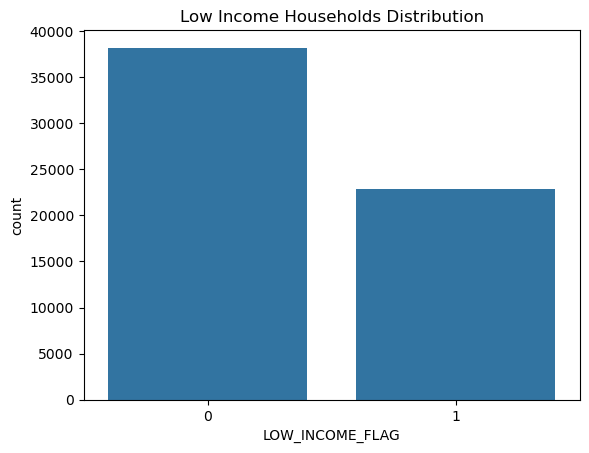

In [35]:
sns.countplot(x='LOW_INCOME_FLAG', data=df)
plt.title("Low Income Households Distribution")
plt.show()

### 3. People qualified for SNAP but NOT receiving it --> We will use TARGET_GAP == 1.
 

In [15]:
gap = df[df['TARGET_GAP'] == 1]

print("Eligible but NOT receiving SNAP:", len(gap))
print("Percentage:", len(gap) / len(df) * 100)

Eligible but NOT receiving SNAP: 4929
Percentage: 8.070933831114605


Compare with poor:

How many poor households are missing SNAP?

                  SNAP VS POVERTY

In [40]:
pd.crosstab(df['LOW_INCOME_FLAG'], df['TARGET_GAP'], normalize='index')

TARGET_GAP,0,1
LOW_INCOME_FLAG,,
0,0.974666,0.025334
1,0.826994,0.173006


### 4.Households eligible for SNAP but NOT receiving it
#### SNAP Eligibility Gap Analysis


In [51]:
gap = df[df['TARGET_GAP'] == 1]

gap.describe()

,PUMA,TARGET_GAP,HAS_ELDERLY,HAS_DISABLED,NUM_CHILDREN,NUM_WORKING_ADULTS,MAX_EDUCATION,IS_MINORITY_HH,VEH,ACCESSINET,...,SMARTPHONE_ONLY,INTERNET_DEVICE_INTERACTION,HOUSING_QUALITY_INDEX,AMENITY_COUNT,LOW_AMENITIES,LIMITED_ENGLISH,ENGLISH_ONLY,PERSONS_PER_ROOM,CROWDED_HH,CHILD_AND_SENIOR_HH
count,4929.000000,4929.0,4929.000000,4929.000000,4929.000000,4929.000000,4929.000000,4929.000000,4929.000000,4929.000000,...,4929.000000,4929.000000,4929.000000,4929.000000,4929.000000,4929.000000,4929.000000,4929.000000,4929.000000,4929.000000
mean,17644.400487,1.0,0.546155,0.330087,0.353621,0.569892,18.192331,0.444106,1.405559,1.328667,...,0.002029,0.017042,6.403124,0.051735,0.993305,0.051938,0.812741,0.402675,0.001826,0.012781
std,25654.572020,0.0,0.497916,0.470292,0.898528,0.767408,3.602445,0.496916,1.040601,0.710765,...,0.045001,0.215364,0.680490,0.477541,0.081557,0.221923,0.390159,0.326475,0.042696,0.112342
min,101.000000,1.0,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.052632,0.000000,0.000000
25%,1003.000000,1.0,0.000000,0.000000,0.000000,0.000000,16.000000,0.000000,1.000000,1.000000,...,0.000000,0.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.200000,0.000000,0.000000
50%,5908.000000,1.0,1.000000,0.000000,0.000000,0.000000,19.000000,0.000000,1.000000,1.000000,...,0.000000,0.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.333333,0.000000,0.000000
75%,17700.000000,1.0,1.000000,1.000000,0.000000,1.000000,21.000000,1.000000,2.000000,1.000000,...,0.000000,0.000000,7.000000,0.000000,1.000000,0.000000,1.000000,0.500000,0.000000,0.000000
max,81003.000000,1.0,1.000000,1.000000,8.000000,6.000000,24.000000,1.000000,6.000000,3.000000,...,1.000000,3.000000,7.000000,6.000000,1.000000,1.000000,1.000000,5.000000,1.000000,1.000000


In [50]:
df['TARGET_GAP'].value_counts(normalize=True)

TARGET_GAP
0    0.919291
1    0.080709
Name: proportion, dtype: float64

Households in the SNAP gap are characterized by significantly lower income, higher rent burden, and a high prevalence of elderly and disabled individuals. These findings suggest that the gap population represents a highly vulnerable group that may face barriers to accessing assistance programs.

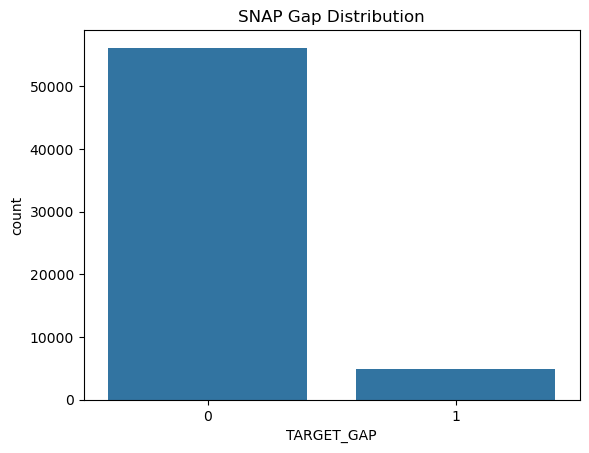

In [52]:
sns.countplot(x='TARGET_GAP', data=df)
plt.title("SNAP Gap Distribution")
plt.show()

In [53]:
df['TARGET_GAP'].value_counts(normalize=True)

TARGET_GAP
0    0.919291
1    0.080709
Name: proportion, dtype: float64

###  SNAP Gap Analysis

Approximately 8% of households are eligible for SNAP but are not receiving benefits.  
This represents a critical gap in assistance programs.

### 5.Group Comparison (Gap vs Non-Gap)

In [55]:
df.groupby('TARGET_GAP')[['NUM_CHILDREN', 'LOG_INCOME', 'RENT_BURDEN']].mean()

,NUM_CHILDREN,LOG_INCOME,RENT_BURDEN
TARGET_GAP,,,
0,0.483862,7.885230,0.038438
1,0.353621,3.291046,0.274498


### Insight: Gap vs Non-Gap Comparison

Compared to other households, SNAP gap households:
- Have significantly lower income
- Experience higher rent burden
- Have slightly fewer children

This reinforces the conclusion that these households are financially stressed.

### 6.Housing Stress Analysis

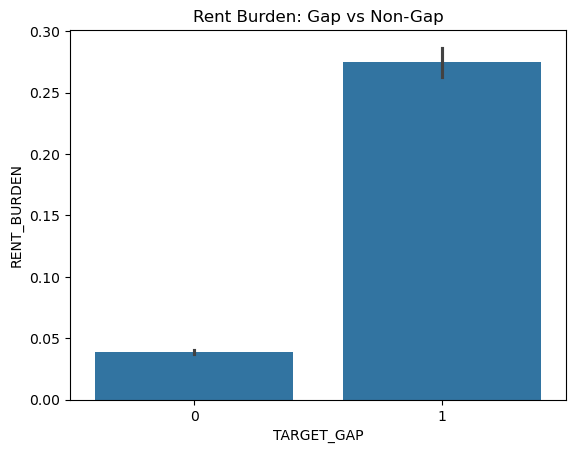

In [34]:
sns.barplot(x='TARGET_GAP', y='RENT_BURDEN', data=df)
plt.title("Rent Burden: Gap vs Non-Gap")
plt.show()

### Housing Burden

Households in the SNAP gap experience significantly higher rent burden, 
indicating increased financial stress and housing instability.

### 7. Children Analysis
#### Average number of children per household

In [17]:
df['NUM_CHILDREN'].mean()

np.float64(0.473350690180282)

In [18]:
df['NUM_CHILDREN'].describe()

count    61071.000000
mean         0.473351
std          0.926233
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max         10.000000
Name: NUM_CHILDREN, dtype: float64

# Do poor households have more children?

In [23]:
df.groupby('LOW_INCOME_FLAG')['NUM_CHILDREN'].mean()

LOW_INCOME_FLAG
0    0.717055
1    0.067159
Name: NUM_CHILDREN, dtype: float64

In [20]:
df['LOW_INCOME_FLAG'].value_counts()

LOW_INCOME_FLAG
0    38170
1    22901
Name: count, dtype: int64

In [21]:
df.groupby('LOW_INCOME_FLAG')['LOG_INCOME'].mean()

LOW_INCOME_FLAG
0    11.732717
1     0.483662
Name: LOG_INCOME, dtype: float64


### Insight: Children and Income

Contrary to expectations, low income households have fewer children on average.

Further analysis shows that these households are more likely to include elderly individuals, 
which explains the lower number of children.

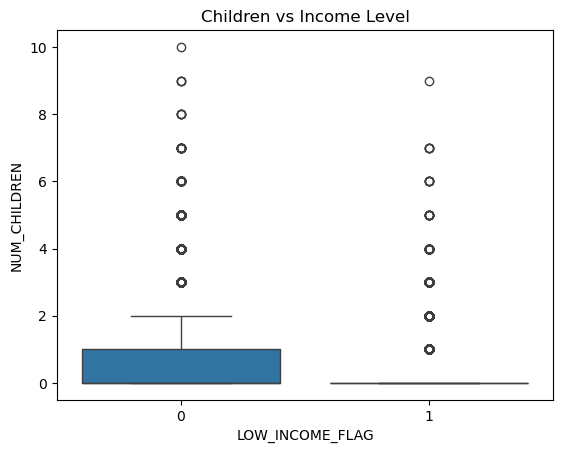

In [38]:
sns.boxplot(x='LOW_INCOME_FLAG', y='NUM_CHILDREN', data=df)
plt.title("Children vs Income Level")
plt.show()

### 8.Elderly Analysis

In [47]:
df.groupby('LOW_INCOME_FLAG')['HAS_ELDERLY'].mean()

LOW_INCOME_FLAG
0    0.45837
1    0.50107
Name: HAS_ELDERLY, dtype: float64

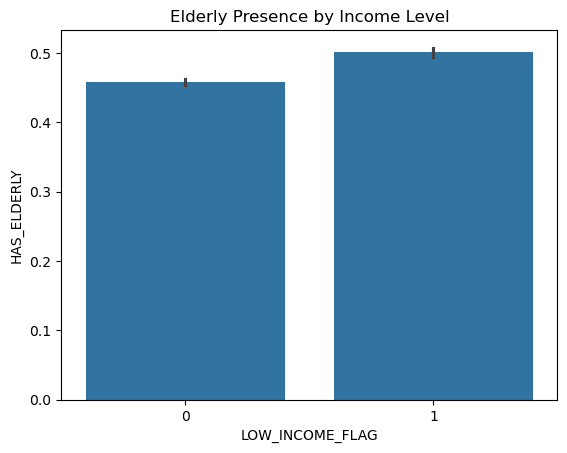

In [48]:
sns.barplot(x='LOW_INCOME_FLAG', y='HAS_ELDERLY', data=df)
plt.title("Elderly Presence by Income Level")
plt.show()

### Insight: Elderly Population

Low-income households have a higher proportion of elderly individuals.  
This explains why they tend to have fewer children and highlights a different form of vulnerability.

### 9. Correlation Heatmap

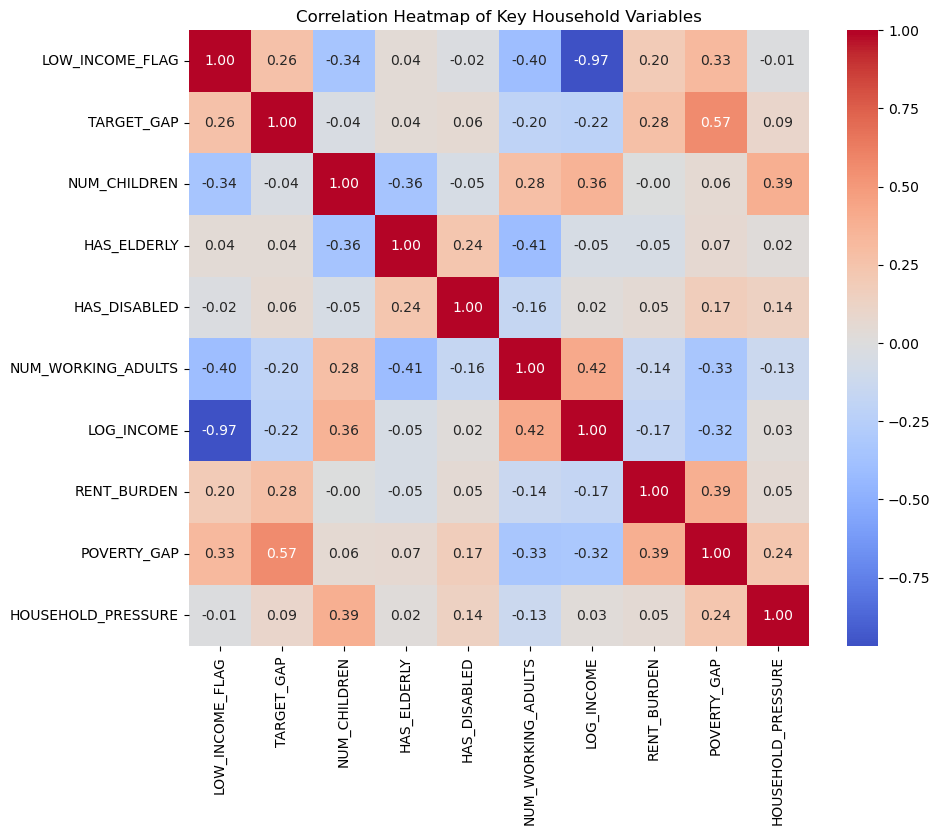

In [43]:

cols = [
    'LOW_INCOME_FLAG', 'TARGET_GAP', 'NUM_CHILDREN', 'HAS_ELDERLY',
    'HAS_DISABLED', 'NUM_WORKING_ADULTS', 'LOG_INCOME',
    'RENT_BURDEN', 'POVERTY_GAP', 'HOUSEHOLD_PRESSURE'
]

corr_matrix = df[cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title("Correlation Heatmap of Key Household Variables")
plt.show()

1- The correlation analysis reveals strong relationships between income, poverty, and SNAP eligibility gaps. 

2- Households in the SNAP gap are significantly associated with higher poverty levels and increased housing burden. 

3- Demographic factors such as the presence of elderly individuals explain variations in household composition, including the number of children

### 10.Data Limitation

The dataset does not include a direct variable indicating SNAP participation.  
Therefore, SNAP receipt cannot be directly measured and is inferred using proxy variables such as income level and TARGET_GAP.